# Create travel time grids

Create travel time grid using Pykonal, more info in original publication : DOI: 10.1785/0220190318 <br>
https://www.researchgate.net/publication/341889419_PyKonal_A_Python_Package_for_Solving_the_Eikonal_Equation_in_Spherical_and_Cartesian_Coordinates_Using_the_Fast_Marching_Method <br>
Pykonal documentation : https://malcolmw.github.io/pykonal-docs/index.html

In [2]:
# standard data handling 
import numpy as np
import pandas as pd
import xarray as xr
# create progress bar 
from tqdm import tqdm
# plot
from matplotlib import pyplot as plt
# Convert UTM to other projection
import utm
# Ray tracing tool 
import pykonal
from pykonal.transformations import geo2sph

import sys
import os

sys.path.append(os.path.abspath("../src"))
from fct_ttime_grid import *

## 1) Load Velocity model 

<u> Model dimensions </u> <br>
When choosing your model dimension you mush insure that all sensor are within the model space <br>
To do so you have 3 ranges to decide : <br>
* depth : in positive number of km (ie 5 km depth = 5, 200m above sea level = -0.2)<br>
* latitude : in ° N <br>
* longitude : in ° E <br> <br>

Velocity data will be coming either from a **1D velocity profile** in a .csv or using a **homogeneous** space <br>
Your velocity information must be in km/s
<br><br>
**KEY STEP : MAKE SURE TO USE °N, °E and correct depth**

### 1D model from .CSV file 

Values can be found in the Data/velocity_profile folder.<br>
For each model you need:<br> 
A) 1D velocity profile<br>
B) The boundaries of the model (given in the READ_ME.txt files)


In [16]:
file_name = 'Layered_model'
FILEPATH_VELOCITY = os.path.abspath("../Data/velocity_profile/{}.csv".format(file_name))
depths = np.linspace(-0.2, 0.2, 100) # range of depth values
latitudes = np.linspace(50.8228677, 50.8213637,100) # range of latitude values 
longitudes = np.linspace(4.3847586,  4.3887782, 100) # range of longitude values 

phase = 'Vs' # Name of your column in the CSV file to use

smoothing_window = 4 # smoothing over n consecutive element of the depth range 

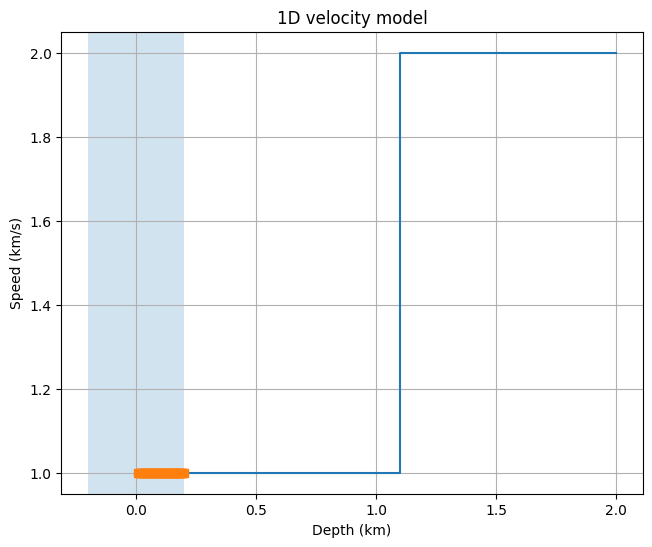

In [17]:
# Be carefull with the usecols, it may remove your column, 
velocity_layers = pd.read_csv(
    FILEPATH_VELOCITY,
    index_col=0)

velocity_layers.index.name = "depth"


# quick visualisation
velocity_layers.T

velocity_layers_interp = velocity_layers.reindex(depths, method="ffill")
padded_data = np.pad(velocity_layers_interp[phase].values, pad_width=smoothing_window//2, mode='edge')

# smoothing on model
if smoothing_window %2 != 0:
    velocity_layers_interp[phase] = np.convolve(padded_data, np.ones(smoothing_window)/smoothing_window, mode = 'valid')[:]
if smoothing_window %2 == 0:
    velocity_layers_interp[phase] = np.convolve(padded_data, np.ones(smoothing_window)/smoothing_window, mode = 'valid')[:-1]


velocity_layers[phase].plot(drawstyle="steps-post")
velocity_layers_interp.sort_values("depth")[phase].plot(
    drawstyle="steps-post",
    xlabel="Depth (km)",
    ylabel="Speed (km/s)",
    title="1D velocity model",
    ax=plt.gca(),
    grid=True,
    figsize=(7.5, 6),
    marker="s",
    ls=""
)
plt.axvspan(depths.min(), depths.max(), alpha=0.2) # Labels and legends
#plt.legend(["P", "S", "P interpolated", "S interpolated", "Domain"])
plt.show()
#### La Palma

velocities = velocity_layers_interp.stack().to_xarray()
velocities = velocities.rename({"level_1": "phase"})
velocities = velocities.sel(phase = phase)
velocity_model = velocities.expand_dims(latitude=latitudes, longitude=longitudes)

### Homogeneous velocity model
projection : spherical

In [4]:
C = 0.400 # velocity in km/s

depths = np.linspace(-2, 1, 100) # depth range 
latitudes = np.linspace(63.81810, 64.03551,100) # latitude range 
longitudes = np.linspace(-22.62691, -21.94679, 100) # longitude range 


In [10]:
# Create a 3D array filled with the value C
data = np.full((len(depths), len(latitudes), len(longitudes)), C)

# Create the DataArray
velocity_model = xr.DataArray(
    data,
    coords={
        "depth": depths,
        "latitude": latitudes,
        "longitude": longitudes
    },
    dims=["depth", "latitude", "longitude"],
    name="velocity"
)

## 2) Pre-processing

### 2.1 Node spacing
Insure that the model has homogeneous spacing along all dimension 

In [20]:
### resample velocity grid ###
n_lat_sample = 100 # number of lat sample for new grid 
n_lon_sample = 101 # number of lon sample for new grid 
n_dep_sample = 102 # number of sample for new depth grid 

lat_ratio = velocity_model.coords['latitude'].shape[0]/n_lat_sample
lon_ratio = velocity_model.coords['longitude'].shape[0]/n_lon_sample
dep_ratio = velocity_model.coords['depth'].shape[0]/n_dep_sample

### CORE ###
new_lat = np.linspace(velocity_model.coords['latitude'][0], velocity_model.coords['latitude'][-1], n_lat_sample)
new_lon = np.linspace(velocity_model.coords['longitude'][0], velocity_model.coords['longitude'][-1], n_lon_sample)
new_dep = np.linspace(velocity_model.coords['depth'][0], velocity_model.coords['depth'][-1], n_dep_sample)

velocity_model = velocity_model.interp(latitude = new_lat, longitude = new_lon, depth = new_dep, method='linear')


### 2.2 Orientation of the grid
Make sure that the array is in the proper orientation as expected by Pykonal. <br>
The reference point is the **deepest**, **northest**, **westest** point of the grid. <br>
If you used °N, °E and km, then the reference point should be a maximum in your latitude value, a minimum in logitude and a maximum in depth. 




In [30]:
ref_lon = 'min'
ref_lat = 'max'
ref_depth = 'max'

# Ensure coordinates are in descending order
if velocity_model.latitude.values[0] > velocity_model.latitude.values[-1] and ref_lat == 'min' :
    velocity_model = velocity_model.sortby("latitude", ascending=True)
if velocity_model.latitude.values[0] < velocity_model.latitude.values[-1] and ref_lat == 'max' :
    velocity_model = velocity_model.sortby("latitude", ascending=False)

if velocity_model.longitude.values[0] > velocity_model.longitude.values[-1] and ref_lon == 'min' :
    velocity_model = velocity_model.sortby("longitude", ascending=True)
if velocity_model.longitude.values[0] < velocity_model.longitude.values[-1] and ref_lon == 'max' :
    velocity_model = velocity_model.sortby("longitude", ascending=False)

if velocity_model.depth.values[0] > velocity_model.depth.values[-1] and ref_depth == 'min' :
    velocity_model = velocity_model.sortby("depth", ascending=True)
if velocity_model.depth.values[0] < velocity_model.depth.values[-1] and ref_depth == 'max' :
    velocity_model = velocity_model.sortby("depth", ascending=False)


Just a quick plot to make sure that everything is OK. <br> 
However, ploting the values arrange them in the wanted order. The values might not be stored in that order and could be fed in the wrong direction if step 2.2 is not done proprely!

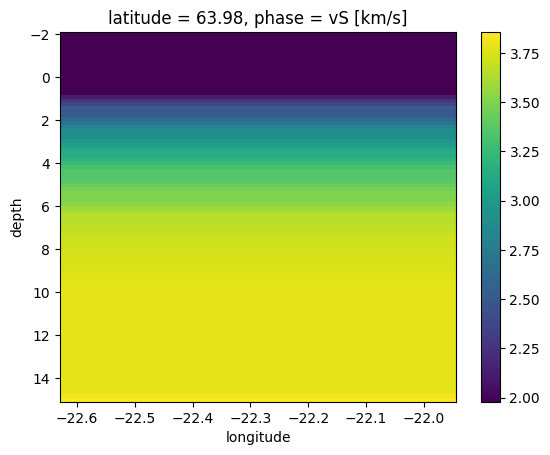

In [31]:
velocity_model.isel(latitude =25).plot(x = 'longitude')
plt.gca().invert_yaxis()

## 3) Lowpass to respect high frequency assumption

To insure the high frequency assumption needed to work with the Eikonal equations (Ray theory), we need to apply a low pass filter. <br> 
We do so using a convolution with a gaussian window, to remove any object smaller than 10 wavelength (D). <br>
The stadard deviation ($\sigma$) of the gaussian needed for an attenuation of 0.99 for an ellement of size D is given by: <br>
$\sigma = \frac{D}{\pi}\sqrt{2ln(0.99)}$

In [32]:
velocity_model = spatial_lowpass (velocity_model, sigma = 1000)

Grid Z spacing: 171.71717171717174
Grid latitude spacing: 244.46546666666777
Grid longitude spacing: 334.8214048019161


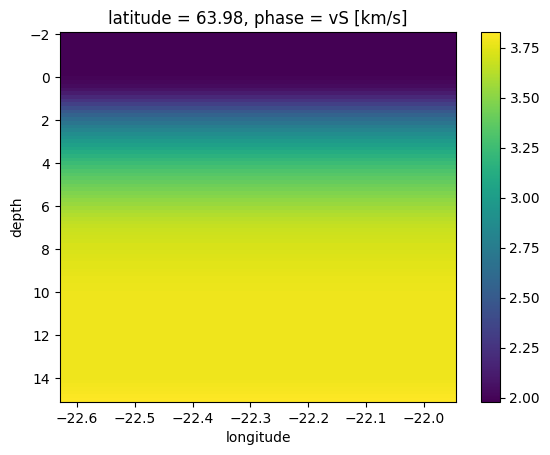

In [33]:
velocity_model.isel(latitude =25).plot(x = 'longitude')
plt.gca().invert_yaxis()

## 4) Load station information

Make sure your station are in °N, °E and depth in km with positif values below sea level increasing as you go deeper. Otherwise they will be outside of the model

In [34]:
### path to station info ###
station_info_path = r'C:\Users\liliv\Desktop\Fagradalfjall\ttime_gid\All_channels\Channel_subset_Fagra.csv'
station_info = pd.read_csv(station_info_path, sep = ',', index_col =0)
print(station_info.head(5))
STATION_ENTRIES = ["lat", "lon", "depth"] # order = lat, lon, dep



      distance   Altitude        lon        lat     depth
Name                                                     
0            0  79.449074 -22.314163  63.865142 -0.079449
17          68  79.541550 -22.312941  63.865416 -0.079542
25         100  82.375450 -22.312294  63.865436 -0.082375
37         148  85.254295 -22.311351  63.865332 -0.085254
170        680  58.797287 -22.302457  63.862678 -0.058797


## 5) Calculate travel time grid (SPHERICAL) 

### 5.1 Issues and trouble shooting 


1) the model run but the location of the station (min travel time) is where you expect. <br>
You messed up the grid orientation and should go back there

2) if all values are np.nan (originaly np.inf) in travel time grid <br>it could be caused by the source being defined outside of the model's grid (verify of source parameters, the classic is depth express in meters while pykonals takes km and / or grid dimensions)

### 5.2 Model dimensions and reference points

* reference point = lowest, northest, westest point of the model. <br>
* node interval = distance between adjacent  nodes for: depth from sea level (km), latitude (radians), longitude (radians) [sperical model]

In [35]:
### CREATE MODEL REFERENCE ### 
latitudes = velocity_model.coords['latitude'].values
longitudes = velocity_model.coords['longitude'].values
depths = velocity_model.coords['depth'].values
reference_point = geo2sph((latitudes.max(), longitudes.min(), depths.max()))
print(reference_point)

node_intervals = (
    np.abs(depths[1] - depths[0]),
    np.deg2rad(np.abs(latitudes[1] - latitudes[0])),
    np.deg2rad(np.abs(longitudes[1] - longitudes[0])),
)
print(node_intervals)

[ 6.35600000e+03  4.53165839e-01 -3.94914079e-01]
(0.17171717171717304, 3.832848814921764e-05, 0.00011990235665314664)


### 5.3 Run Pykonal

We have chosen here to create 1 .h5 file per DAS channel. This allows to have good resolution while keeping managable file size for the DAS array. 

In [36]:
### OUTPUT path ###
folder_out = r'C:\Users\liliv\Desktop\DAS_senstivity\test'

### Error with Pykonal 
If you get an error : 'Buffer dtype mismatch, expected 'Py_ssize_t' but got 'long'' with Pykonal when running the next cell, and you are using a windows. <br>
You must fix Pykonal ==> To do so, go in the README there is a full solution.

In [38]:
# transpose velocity model to go from lat lon depth to depth lat lon
velocities = velocity_model.transpose( 'depth','latitude', 'longitude').copy()
# container to keep travel time grids 
ttime_ds = xr.Dataset( coords=velocity_model.coords)

for Station_Name in tqdm(station_info.index):

    ### Create and run model ###
    solver = pykonal.solver.PointSourceSolver(coord_sys="spherical")
    solver.velocity.min_coords = reference_point
    solver.velocity.node_intervals = node_intervals
    solver.velocity.npts = velocities.values.shape
    solver.velocity.values = velocities.values
    # Initialize the source location with a random location within the
    # computational grid.
    # Source
    src_loc = station_info.loc[Station_Name][STATION_ENTRIES].values
    solver.src_loc = np.array(geo2sph(src_loc).squeeze()) # 

    # Compute traveltimes.
    solver.solve()

    tt = solver.tt.values
    tt[np.isinf(tt)] = np.nan
    travel_times = velocities.copy()
    travel_times.values  = tt
    travel_times.to_netcdf(folder_out+'\\'+str(Station_Name)+'.h5')


  0%|          | 0/29 [00:00<?, ?it/s]

100%|██████████| 29/29 [02:56<00:00,  6.07s/it]
